In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

from astropy.table import Table
from astropy.io import fits

import seaborn as sns
from matplotlib.animation import PillowWriter

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import TwoSlopeNorm


mpl.rcParams.update({
    "font.family": "serif",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "errorbar.capsize": 5,
    "axes.linewidth": 2,
    "xtick.major.size": 16,
    "xtick.major.width": 2,
    "xtick.minor.size": 8,
    "xtick.minor.width": 1,
    "ytick.major.size": 16,
    "ytick.major.width": 2,
    "ytick.minor.size": 8,
    "ytick.minor.width": 1,
    "axes.labelsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "legend.fontsize": 18,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.right": True,
    "xtick.top": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.title_fontsize": 18,
})


In [38]:
def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object to a pandas DataFrame.
    """
    table = Table(fits_rec)

    # Keep only 1D columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]

    df = table[cols].to_pandas()
    df = decode(df)

    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin x_col and compute median of y_col in each bin.
    Returns median and counts.
    """
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    grouped = df.groupby(x_bin_labels, observed=False).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)
    grouped = grouped.rename(columns={
        x_col: 'x_bin',
        'y_median': f'{y_col}_median'
    })

    return grouped

In [39]:
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

two_process_data = fitsrec_to_pandas(twoprocess_data)
data_astronn = fitsrec_to_pandas(astronn_data)

# Identify columns that are NOT already in two_process_data
new_cols = data_astronn.columns.difference(two_process_data.columns)

# Concatenate, keeping two_process_data's versions of duplicate columns
data = pd.concat(
    [
        two_process_data.reset_index(drop=True),
        data_astronn[new_cols].reset_index(drop=True)
    ],
    axis=1
)

data = data[data['DFLAG'] == 0]

data['MG_H'] = data['MG_H_ASPCAP_ADJ']
data['FE_H'] = data['FE_H_ASPCAP_ADJ']
data['MN_H'] = data['MN_H_ASPCAP_ADJ']

data['MN_O'] = data['MN_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['FE_O'] = data['FE_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['MN_MG'] = data['MN_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['FE_MG'] = data['FE_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['MG_FE'] = data['MG_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['MN_FE'] = data['MN_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']

data = data.dropna(subset=['MN_MG'])


pos_FE_H = data[data['FE_H'] > 0]
neg_FE_H = data[data['FE_H'] < 0]

data_high_alpha = pd.concat([
    pos_FE_H[pos_FE_H['MG_FE'] > 0.12],
    neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]
])

data_low_alpha = pd.concat([
    pos_FE_H[pos_FE_H['MG_FE'] < 0.12],
    neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]
])

# Spatial cuts
data_low_alpha = data_low_alpha[
    (data_low_alpha['galz'] < 2) & (data_low_alpha['galz'] > -2) &
    (data_low_alpha['galr'] < 15) & (data_low_alpha['galr'] > 3)
]

data_high_alpha = data_high_alpha[
    (data_high_alpha['galz'] < 2) & (data_high_alpha['galz'] > -2) &
    (data_high_alpha['galr'] < 15) & (data_high_alpha['galr'] > 3)
]

mnmg_high = compute_binned_median(data_high_alpha, 'MG_H', 'MN_MG', n_bins=20)
mnmg_low  = compute_binned_median(data_low_alpha,  'MG_H', 'MN_MG', n_bins=20)

femg_high = compute_binned_median(data_high_alpha, 'MG_H', 'FE_MG', n_bins=20)
femg_low  = compute_binned_median(data_low_alpha,  'MG_H', 'FE_MG', n_bins=20)


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

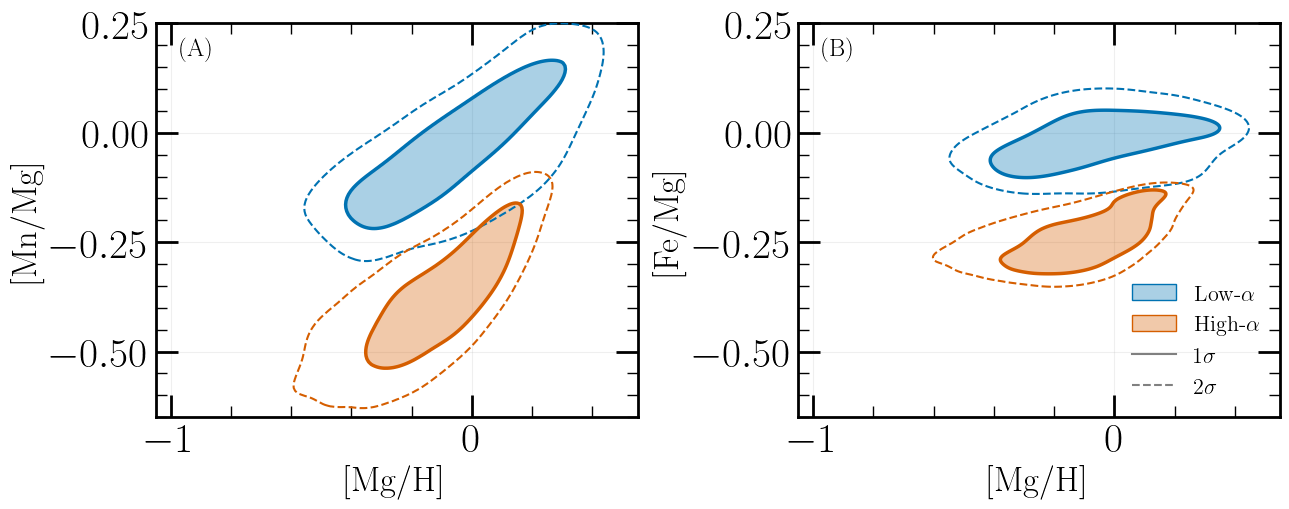

In [40]:
import numpy as np
import matplotlib.pyplot as plt

from getdist import plots, MCSamples
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Color-blind–safe palette
LOW_COLOR  = "#0072B2"   # blue
HIGH_COLOR = "#D55E00"   # vermillion

# GetDist density helper functions
def get_density(x, y):
    arr = np.vstack((x, y)).T
    samples = MCSamples(samples=arr, names=["x", "y"])
    g = plots.get_single_plotter()
    X, Y = g.get_param_array(samples, ["x", "y"])
    dens = g.sample_analyser.get_density_grid(samples, X, Y)
    return dens


def plot_sigma_contours(ax, dens, color):
    """
    1σ: filled + outline
    2σ: outline only
    """
    level_1s = dens.getContourLevels([0.6827])[0]
    level_2s = dens.getContourLevels([0.9545])[0]

    X = dens.x
    Y = dens.y
    P = dens.P

    # --- 1σ filled ---
    ax.contourf(
        X, Y, P,
        levels=[level_1s, np.max(P)],
        colors=[color + "55"],
        zorder=2
    )

    # --- 1σ outline ---
    ax.contour(
        X, Y, P,
        levels=[level_1s],
        colors=[color],
        linewidths=2.5,
        zorder=3
    )

    # --- 2σ outline ---
    ax.contour(
        X, Y, P,
        levels=[level_2s],
        colors=[color],
        linewidths=1.5,
        linestyles="--",
        zorder=3
    )

# Compute densities
dens_mnmg_low  = get_density(data_low_alpha["MG_H"], data_low_alpha["MN_MG"])
dens_mnmg_high = get_density(data_high_alpha["MG_H"], data_high_alpha["MN_MG"])

dens_femg_low  = get_density(data_low_alpha["MG_H"], data_low_alpha["FE_MG"])
dens_femg_high = get_density(data_high_alpha["MG_H"], data_high_alpha["FE_MG"])

# Figure 
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# Panel A — [Mn/Mg]
ax = axes[0]

#ax.scatter(
#    data_low_alpha["MG_H"], data_low_alpha["MN_MG"],
#    s=0.5, alpha=0.12, color=LOW_COLOR, zorder=1
#)
#ax.scatter(
#    data_high_alpha["MG_H"], data_high_alpha["MN_MG"],
#    s=0.5, alpha=0.12, color=HIGH_COLOR, zorder=1
#)

plot_sigma_contours(ax, dens_mnmg_low,  LOW_COLOR)
plot_sigma_contours(ax, dens_mnmg_high, HIGH_COLOR)

#ax.scatter(
    #mnmg_low["x_center"], mnmg_low["MN_MG_median"],
    #marker="*", s=90, color=LOW_COLOR,
    #edgecolor="black", zorder=5
#)
#ax.scatter(
    #mnmg_high["x_center"], mnmg_high["MN_MG_median"],
    #marker="*", s=90, color=HIGH_COLOR,
    #edgecolor="black", zorder=5
#)

ax.set_xlabel(r"[Mg/H]", fontsize = 25)
ax.set_ylabel(r"[Mn/Mg]", fontsize = 25)
ax.set_xlim(-1.05, 0.55)
ax.set_ylim(-0.65, 0.25)

ax.grid(alpha=0.2)
ax.text(0.05, 0.92, "(A)", transform=ax.transAxes,
        fontsize=18, fontweight="bold")

# Panel B — [Fe/Mg]
ax = axes[1]

#ax.scatter(
   # data_low_alpha["MG_H"], data_low_alpha["FE_MG"],
   # s=0.5, alpha=0.12, color=LOW_COLOR, zorder=1
#)
#ax.scatter(
#    data_high_alpha["MG_H"], data_high_alpha["FE_MG"],
#    s=0.5, alpha=0.12, color=HIGH_COLOR, zorder=1
#)

plot_sigma_contours(ax, dens_femg_low,  LOW_COLOR)
plot_sigma_contours(ax, dens_femg_high, HIGH_COLOR)

#ax.scatter(
    #femg_low["x_center"], femg_low["FE_MG_median"],
    #marker="*", s=90, color=LOW_COLOR,
    #edgecolor="black", zorder=5
#)
#ax.scatter(
    #femg_high["x_center"], femg_high["FE_MG_median"],
    #marker="*", s=90, color=HIGH_COLOR,
    #edgecolor="black", zorder=5
#)

ax.set_xlabel(r"[Mg/H]", fontsize = 25)
ax.set_ylabel(r"[Fe/Mg]", fontsize = 25)
ax.set_xlim(-1.05, 0.55)
ax.set_ylim(-0.65, 0.25)

#ax.set_box_aspect(1)

ax.grid(alpha=0.2)
ax.text(0.05, 0.92, "(B)", transform=ax.transAxes,
        fontsize=18, fontweight="bold")

# Legend (σ regions + populations + medians)
LOW_PATCH = Patch(facecolor=LOW_COLOR+"55", edgecolor=LOW_COLOR,
                  label=r"Low-$\alpha$")

HIGH_PATCH = Patch(facecolor=HIGH_COLOR+"55", edgecolor=HIGH_COLOR,
                   label=r"High-$\alpha$")

SIG1 = Line2D([0], [0], color="gray", lw=1.5,
              linestyle="-", label=r"$1\sigma$")
SIG2 = Line2D([0], [0], color="gray", lw=1.5,
              linestyle="--", label=r"$2\sigma$")

#MEDIAN = Line2D([0], [0], marker="*", linestyle="None",
                #markersize=12, color="black", label="Median")


ax.legend(
    handles=[LOW_PATCH, HIGH_PATCH, SIG1, SIG2],
    frameon=False, loc="lower right", fontsize=16,
)

plt.tight_layout()
plt.show()


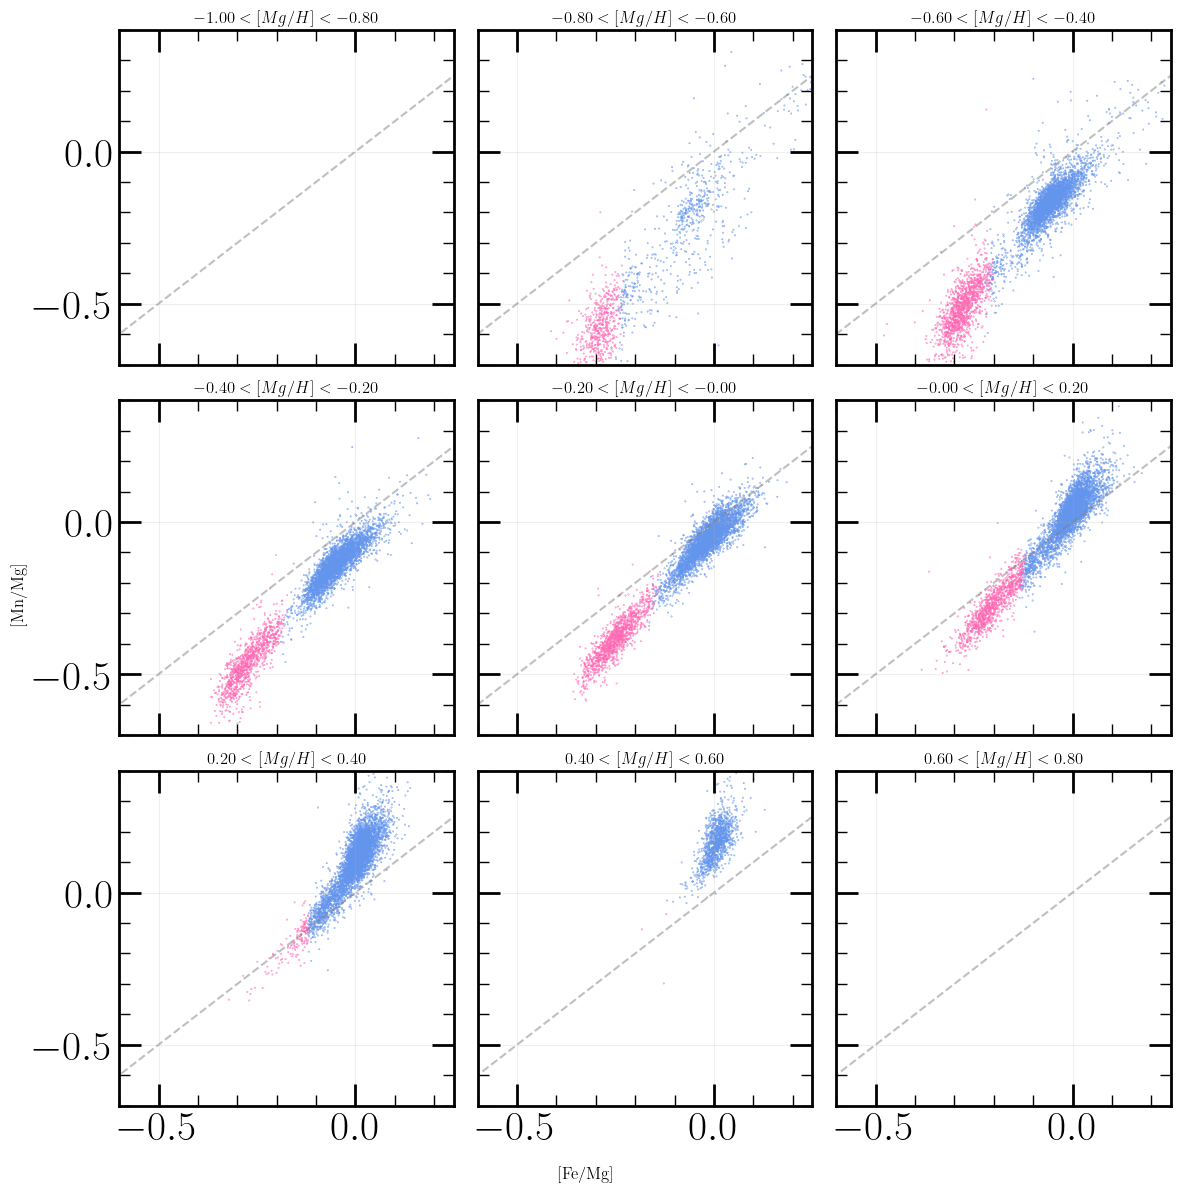

In [41]:
mg_h_bin_edges     = np.arange(-0.6, 0.3, 0.1)
mg_h_big_bin_edges = np.arange(-1.0, 1.0, 0.2)

data_high_alpha['high_low_alpha'] = 'high'
data_low_alpha['high_low_alpha']  = 'low'

data_high_alpha['color'] = 'hotpink'
data_low_alpha['color']  = 'cornflowerblue'

data_all = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)
data_all = data_all[data_all['zmax'] < 5]

data_all['MG_H_bin'] = pd.cut(
    data_all['MG_H'], bins=mg_h_bin_edges, right=False, labels=False
)

data_all['MG_H_big_bin'] = pd.cut(
    data_all['MG_H'], bins=mg_h_big_bin_edges, right=False, labels=False
)

def downsample(df, N):
    return df.sample(N, random_state=42) if len(df) > N else df

fig, axes = plt.subplots(3, 3, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    df = data_all[data_all['MG_H_big_bin'] == i]
    df = downsample(df, 5000)

    ax.scatter(df['FE_MG'], df['MN_MG'], s=0.1, color=df['color'])

    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', color='gray', alpha=0.5)

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$'
    )

    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)
    ax.grid(alpha=0.2)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
plt.tight_layout()
plt.show()

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


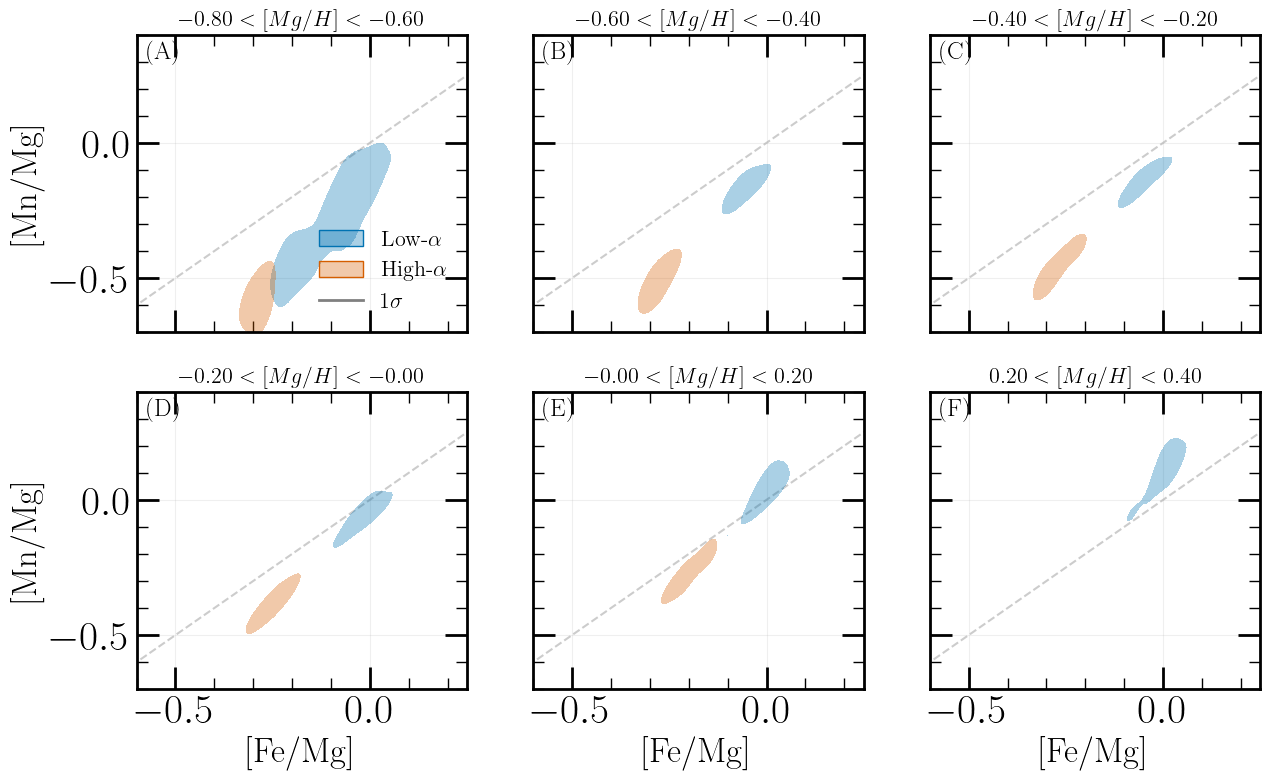

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

...

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Color-blind–safe palette
LOW_COLOR  = "#0072B2"   # blue
HIGH_COLOR = "#D55E00"   # vermillion

# GetDist density helper functions
def get_density(x, y):
    arr = np.vstack((x, y)).T
    samples = MCSamples(samples=arr, names=["x", "y"])
    g = plots.get_single_plotter()
    X, Y = g.get_param_array(samples, ["x", "y"])
    dens = g.sample_analyser.get_density_grid(samples, X, Y)
    return dens


def plot_1sigma_contour(ax, dens, color):
    level_1s = dens.getContourLevels([0.6827])[0]

    X, Y, P = dens.x, dens.y, dens.P

    # 1σ filled
    ax.contourf(
        X, Y, P,
        levels=[level_1s, np.max(P)],
        colors=[color + "55"],
        zorder=2
    )

    # 1σ outline
   # ax.contour(
        #X, Y, P,
        #levels=[level_1s],
        #colors=[color],
       # linewidths=2.0,
       # zorder=3
    #)

# Figure: 2 rows × 3 columns (panels 1–6)
fig, axes = plt.subplots(
    2, 3,
    figsize=(14.5, 8.5),
    sharex=True,
    sharey=True
)
axes = axes.flatten()
panel_ids = range(1, 7)  # panels 1–6 only

# Letters for panel labels
panel_labels = ["(A)", "(B)", "(C)", "(D)", "(E)", "(F)"]


# Loop over panels
for idx, (ax, i) in enumerate(zip(axes, panel_ids)):

    df = data_all[data_all['MG_H_big_bin'] == i]
    df = downsample(df, 5000)

    # Background scatter
    #ax.scatter(
       # df['FE_MG'], df['MN_MG'],
       # s=0.15,
       # color=df['color'],
       # alpha=0.12,
       # zorder=1
    #)

    # Diagonal reference line
    xs = np.linspace(-0.8, 0.4, 200)
    ax.plot(xs, xs, '--', color='gray', alpha=0.4, zorder=0)

    # KDE + 1σ contours per α population
    for label, color in [("low", LOW_COLOR), ("high", HIGH_COLOR)]:
        sub = df[df['high_low_alpha'] == label]
        if len(sub) < 200:
            continue
        dens = get_density(sub['FE_MG'].values, sub['MN_MG'].values)
        plot_1sigma_contour(ax, dens, color)

    # Panel titles
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=16
    )

    # Axis limits
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)
    ax.grid(alpha=0.2)

    # Panel labels (top-left)
    ax.text(0.03, 0.92, panel_labels[idx],
            transform=ax.transAxes, fontsize=18, fontweight="bold")

    # Y-labels only on first column
    if idx % 3 == 0:
        ax.set_ylabel(r"[Mn/Mg]", fontsize=25)
    else:
        ax.set_ylabel("")

    # X-labels only on bottom row
    if idx // 3 == 1:
        ax.set_xlabel(r"[Fe/Mg]", fontsize=25)
    else:
        ax.set_xlabel("")

# Legend (first panel only)
LOW_PATCH = Patch(facecolor=LOW_COLOR+"55", edgecolor=LOW_COLOR, label=r"Low-$\alpha$")
HIGH_PATCH = Patch(facecolor=HIGH_COLOR+"55", edgecolor=HIGH_COLOR, label=r"High-$\alpha$")
SIG1 = Line2D([0], [0], color="gray", lw=2.0, linestyle="-", label=r"$1\sigma$")

axes[0].legend(handles=[LOW_PATCH, HIGH_PATCH, SIG1], frameon=False, loc="lower right", fontsize=16)

plt.tight_layout()
plt.show()


In [57]:
from chemevo import evolution as evo

mg_h_big_bin_edges = np.arange(-0.8, 0.4, 0.2) 
mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

data_all['MG_H_bin'] = pd.cut(data_all['MG_H'], bins = mg_h_bin_edges, right=False, labels=False)
data_all['MG_H_big_bin'] = pd.cut(data_all['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)

xs = np.linspace(-1, 1, 100)

def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df
    
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]

m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_exp /= np.trapezoid(m_g_array_exp, t_array)

etas = [0, 0.5, 1]
tau_stars = [0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6]
colors_lines = ['blue', 'orange', 'green', 'red', 'purple', 'teal', 'magenta', 'brown', 'navy', 'maroon']
colors_dots = ['greenyellow', 'cyan', 'orange', 'blue', 'red', 'yellow', 'green', 'gray', 'peru', 'navy']


def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

tau_1s = [2, 5, 5]
tau_2s = [6, 10, 20]
sfr_1 = rise_fall(t_array, tau_1s[0], tau_2s[0])
sfr_2 = rise_fall(t_array, tau_1s[1], tau_2s[1])
sfr_3 = rise_fall(t_array, tau_1s[2], tau_2s[2])
mask_1 = t_array > 6
sfr_1[mask_1] = 1e-6

# Normalize each SFR so integral over time equals 1
sfr_1 /= np.trapezoid(sfr_1, t_array)
sfr_2 /= np.trapezoid(sfr_2, t_array)
sfr_3 /= np.trapezoid(sfr_3, t_array)

sfrs = [sfr_1, sfr_2, sfr_3]


gals_taustar_eta0 = []
gals_taustar_eta1 = []
gals_taustar_eta2 = []

#gals_taustar_sfrconst = []
gals_taustar_sfrexp = []
gals_taustar_sfr1 = []
gals_taustar_sfr2 = []
gals_taustar_sfr3 = []


gals_eta = []
gals_sfr = []


for i in range(len(tau_stars)):
    gals_taustar_eta0.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0]))

for i in range(len(tau_stars)):
    gals_taustar_eta1.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[1]))

for i in range(len(tau_stars)):
    gals_taustar_eta2.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[2]))



for i in range(len(tau_stars)):
    gals_taustar_sfrexp.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_exp, tau_star=tau_stars[i], eta=etas[0]))

for i in range(len(tau_stars)):
    gals_taustar_sfr1.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=sfrs[0], tau_star=tau_stars[i], eta=etas[0]))

for i in range(len(tau_stars)):
    gals_taustar_sfr2.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=sfrs[1], tau_star=tau_stars[i], eta=etas[0]))

for i in range(len(tau_stars)):
    gals_taustar_sfr3.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=sfrs[2], tau_star=tau_stars[i], eta=etas[0]))



for j in range(len(etas)):
    gals_eta.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=1, eta=etas[j]))

for k in range(len(sfrs)):
    gals_sfr.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=sfrs[k], tau_star=1, eta=0))

In [58]:
def find_endpoints(galaxies, bin_centers):
    endpoints_gals = []

    for bin_cent in bin_centers:
        endpoints = []
        for gal in galaxies:
            o_h = gal.O_H
            for indx in range(len(o_h)):
                o_h_at_time = o_h[indx]
                if o_h_at_time > bin_cent:
                    endpoints.append(indx)
                    break

        endpoints_gals.append(np.array(endpoints))

    return endpoints_gals


gals_endpoints = {
    0: find_endpoints(gals_taustar_eta0, mg_h_big_bin_centers),
    1: find_endpoints(gals_taustar_eta1, mg_h_big_bin_centers),
    2: find_endpoints(gals_taustar_eta2, mg_h_big_bin_centers),
}

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Color-blind–safe palette
LOW_COLOR  = "#0072B2"   # blue
HIGH_COLOR = "#D55E00"   # vermillion

# GetDist density helper functions
def get_density(x, y):
    arr = np.vstack((x, y)).T
    samples = MCSamples(samples=arr, names=["x", "y"])
    g = plots.get_single_plotter()
    X, Y = g.get_param_array(samples, ["x", "y"])
    dens = g.sample_analyser.get_density_grid(samples, X, Y)
    return dens


def plot_1sigma_contour(ax, dens, color):
    level_1s = dens.getContourLevels([0.6827])[0]

    X, Y, P = dens.x, dens.y, dens.P

    # 1σ filled
    ax.contourf(
        X, Y, P,
        levels=[level_1s, np.max(P)],
        colors=[color + "55"],
        zorder=2
    )

    # 1σ outline
    #ax.contour(X, Y, P, levels=[level_1s], colors=[color],linewidths=2.0,zorder=3)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


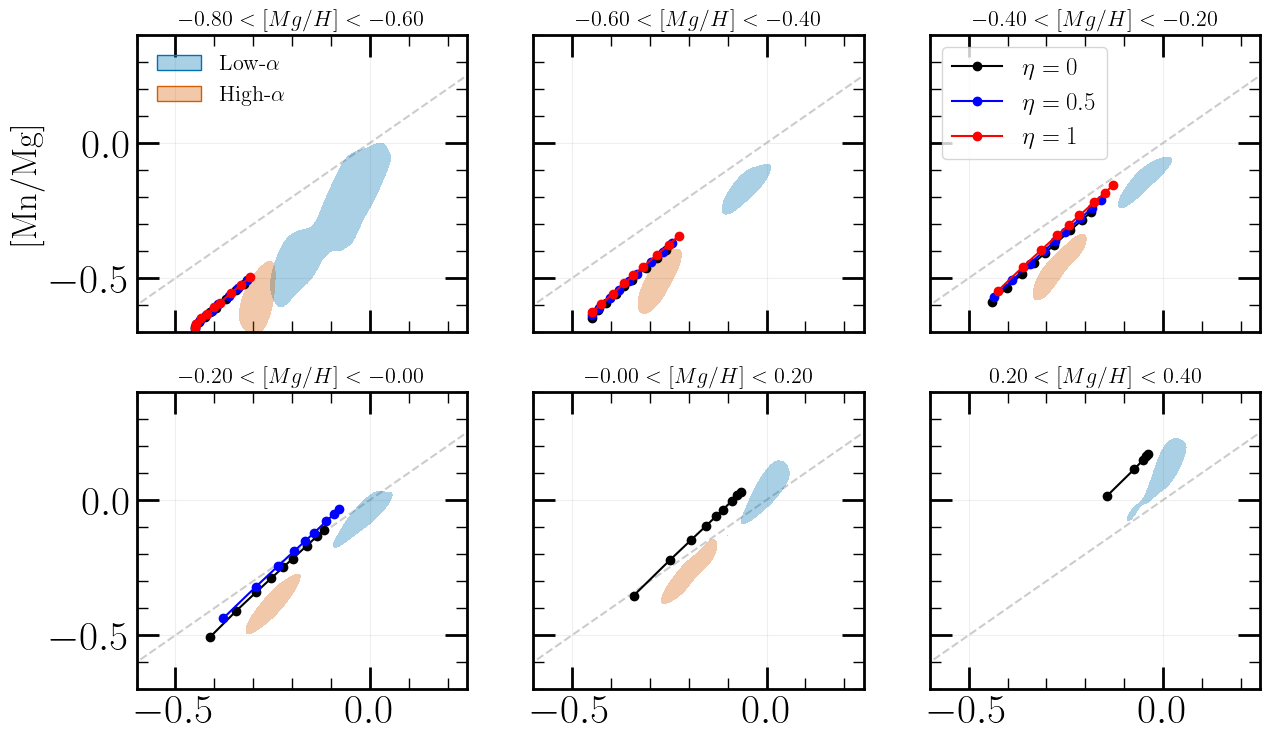

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

...

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [75]:
# Figure: 2 rows × 3 columns (panels 1–6)
fig, axes = plt.subplots(
    2, 3,
    figsize=(14.5, 8.5),
    sharex=True,
    sharey=True
)
axes = axes.flatten()
panel_ids = range(0, 6)  # panels 1–6 only

# Letters for panel labels
panel_labels = ["(A)", "(B)", "(C)", "(D)", "(E)", "(F)"]


# Loop over panels
for idx, (ax, i) in enumerate(zip(axes, panel_ids)):

    df = data_all[data_all['MG_H_big_bin'] == i]
    df = downsample(df, 5000)


    # Diagonal reference line
    xs = np.linspace(-0.8, 0.4, 200)
    ax.plot(xs, xs, '--', color='gray', alpha=0.4, zorder=0)

    # KDE + 1σ contours per α population
    for label, color in [("low", LOW_COLOR), ("high", HIGH_COLOR)]:
        sub = df[df['high_low_alpha'] == label]
        if len(sub) < 200:
            continue
        dens = get_density(sub['FE_MG'].values, sub['MN_MG'].values)
        plot_1sigma_contour(ax, dens, color)


    endpoints_0 = gals_endpoints[0][i]
    fe_mg_eta0 = []
    mn_mg_eta0 = []

    endpoints_1 = gals_endpoints[1][i]
    fe_mg_eta1 = []
    mn_mg_eta1 = []

    endpoints_2 = gals_endpoints[2][i]
    fe_mg_eta2 = []
    mn_mg_eta2 = []

    for gal, idx in zip(gals_taustar_eta0, endpoints_0):
        fe_mg_eta0.append(gal.Fe_Mg[idx])
        mn_mg_eta0.append(gal.Mn_Mg[idx])

    for gal, idx in zip(gals_taustar_eta1, endpoints_1):
        fe_mg_eta1.append(gal.Fe_Mg[idx])
        mn_mg_eta1.append(gal.Mn_Mg[idx])

    for gal, idx in zip(gals_taustar_eta2, endpoints_2):
        fe_mg_eta2.append(gal.Fe_Mg[idx])
        mn_mg_eta2.append(gal.Mn_Mg[idx])

    ax.plot(fe_mg_eta0, mn_mg_eta0, 'o-', color='black', linewidth=1.5, label = rf'$\eta = {etas[0]}$')
    ax.plot(fe_mg_eta1, mn_mg_eta1, 'o-', color='blue', linewidth=1.5, label = rf'$\eta = {etas[1]}$')
    ax.plot(fe_mg_eta2, mn_mg_eta2, 'o-', color='red', linewidth=1.5, label = rf'$\eta = {etas[2]}$')

    if i == 2:
        ax.legend()


    # Panel titles
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=16
    )

    # Axis limits
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)
    ax.grid(alpha=0.2)

    # Y-labels only on first column
    if idx % 3 == 0:
        ax.set_ylabel(r"[Mn/Mg]", fontsize=25)
    else:
        ax.set_ylabel("")

    # X-labels only on bottom row
    if idx // 3 == 1:
        ax.set_xlabel(r"[Fe/Mg]", fontsize=25)
    else:
        ax.set_xlabel("")

# Legend (first panel only)
LOW_PATCH = Patch(facecolor=LOW_COLOR+"55", edgecolor=LOW_COLOR, label=r"Low-$\alpha$")
HIGH_PATCH = Patch(facecolor=HIGH_COLOR+"55", edgecolor=HIGH_COLOR, label=r"High-$\alpha$")
SIG1 = Line2D([0], [0], color="gray", lw=2.0, linestyle="-", label=r"$1\sigma$")

axes[0].legend(handles=[LOW_PATCH, HIGH_PATCH], frameon=False, loc="upper left", fontsize=16)

plt.tight_layout()
plt.show()
